## Bandwidth performance of Multi-core Segmented Operations

> The goal is to understand the "peak performance" of the Multi-core Segmented Operations

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75

_MARKERS = ["o", "^", "v", "<", ">", "s", "X"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 10}

In [76]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [77]:
S = 128

df = pd.DataFrame()

copy_dataframe = pd.read_csv(f"../bench_results_copy_fp32.csv")
copy_dataframe["operator"] = "COPY (fp32)"
copy_dataframe["gelemps"] = (copy_dataframe["size"] / 1e9) / (copy_dataframe["time_us"] / 1e6)
copy_dataframe['mem_bytes'] = (copy_dataframe['size'] * 4)  + copy_dataframe['outputsize'] * 4
copy_dataframe['bandwidth_gbps'] = (copy_dataframe['mem_bytes']) / (copy_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, copy_dataframe])

mcscan_dataframe = pd.read_csv(f"../bench_results_mcscan_{S}_fp16.csv")
mcscan_dataframe["operator"] = "SCAN (fp16)"
mcscan_dataframe["gelemps"] = (mcscan_dataframe["size"] / 1e9) / (mcscan_dataframe["time_us"] / 1e6)
mcscan_dataframe['mem_bytes'] = (mcscan_dataframe['size'] * 2)  + mcscan_dataframe['size'] * 4
mcscan_dataframe['bandwidth_gbps'] = (mcscan_dataframe['mem_bytes']) / (mcscan_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, mcscan_dataframe])


mcscan_dataframe = pd.read_csv(f"../bench_results_mcscan_{S}_int8.csv")
mcscan_dataframe["operator"] = "SCAN (int8)"
mcscan_dataframe["gelemps"] = (mcscan_dataframe["size"] / 1e9) / (mcscan_dataframe["time_us"] / 1e6)
mcscan_dataframe['mem_bytes'] = (mcscan_dataframe['size'] * 1)  + mcscan_dataframe['size'] * 4
mcscan_dataframe['bandwidth_gbps'] = (mcscan_dataframe['mem_bytes']) / (mcscan_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, mcscan_dataframe])

diff_dataframe = pd.read_csv(f"../bench_results_diff_cann_fp32.csv")
diff_dataframe["operator"] = "DIFF (fp32)"
diff_dataframe["gelemps"] = (diff_dataframe["size"] / 1e9) / (diff_dataframe["time_us"] / 1e6)
diff_dataframe['mem_bytes'] = (diff_dataframe['size'] * 4)  + diff_dataframe['outputsize'] * 4
diff_dataframe['bandwidth_gbps'] = (diff_dataframe['mem_bytes']) / (diff_dataframe['time_us'] * 1000) # GB/s
df = pd.concat([df, diff_dataframe])

for density in [0.001, 0.01]:
    # Input -> FP32 + INT8 -> 4 + 1 | Output -> FP32 -> 4
    compress_dataframe = pd.read_csv(f"../bench_results_compress_{S}_{density}_fp32.csv")
    compress_dataframe["operator"] = f"COMPRESS ({density})"
    compress_dataframe["gelemps"] = (compress_dataframe["size"] / 1e9) / (compress_dataframe["time_us"] / 1e6)
    compress_dataframe['mem_bytes'] = (compress_dataframe['size'] * (4+1))  + compress_dataframe['outputsize'] * 4
    compress_dataframe['bandwidth_gbps'] = (compress_dataframe['mem_bytes']) / (compress_dataframe['time_us'] * 1000) #GB/s
    df = pd.concat([df, compress_dataframe])

    # Input -> FP32 + INT32 + FP32 (small)  | Output -> FP32 
    revert_dataframe = pd.read_csv(f"../bench_results_seg_scan_mc_revert_{density}_fp32.csv")
    revert_dataframe["operator"] = f"REVERT ({density})"
    revert_dataframe["gelemps"] = (revert_dataframe["size"] / 1e9) / (revert_dataframe["time_us"] / 1e6)
    revert_dataframe['mem_bytes'] = (revert_dataframe['size'] * 3 * 4)  + revert_dataframe['outputsize'] * 4
    revert_dataframe['bandwidth_gbps'] = (revert_dataframe['mem_bytes']) / (revert_dataframe['time_us'] * 1000) #GB/s
    df = pd.concat([df, revert_dataframe])

## Paper plots

/tmp/ipykernel_3623026/3800447145.py:6: UserWarning: 
The markers list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='bandwidth_gbps', **_SNS_PARAMS)


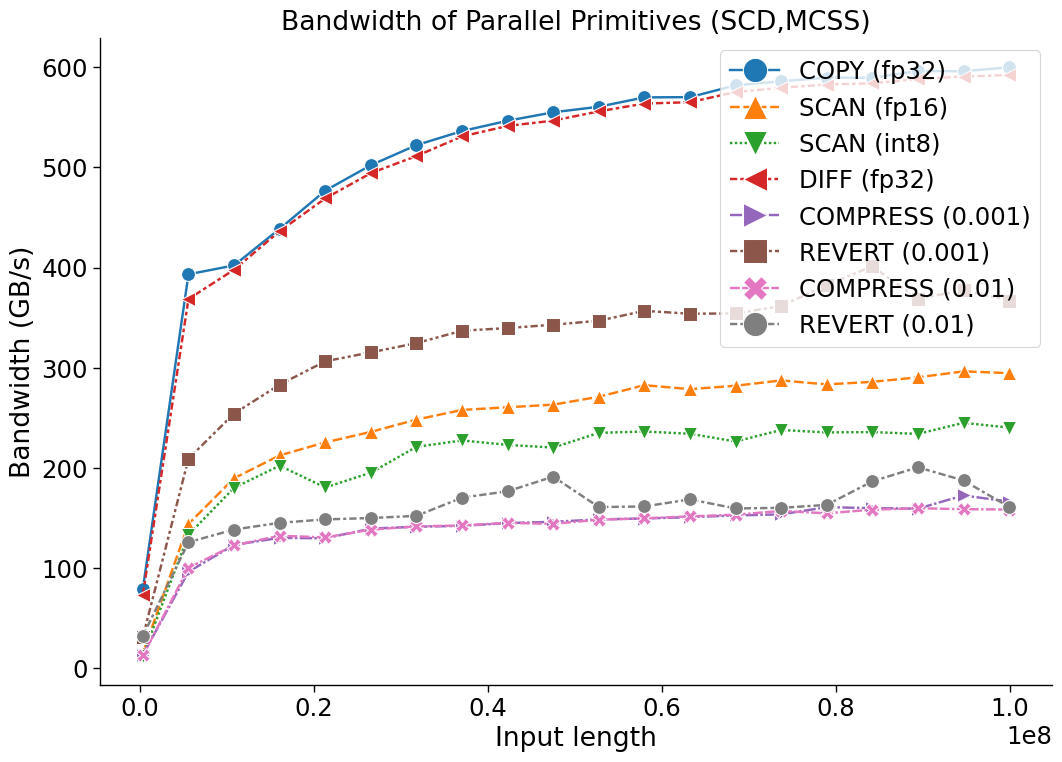

<Figure size 870x627 with 0 Axes>

In [78]:
plt.figure(figsize=(11, 8))


_SNS_PARAMS = {"hue":'operator', "style":'operator', "markers":_MARKERS, "markersize": 10, "dashes":True}

ax = sns.lineplot(data=df, x='size', y='bandwidth_gbps', **_SNS_PARAMS)

ax.set_title(f"Bandwidth of Parallel Primitives (SCD,MCSS)")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(loc="upper right", markerscale=_LEGEND_MARKER_SCALE)
plt.tight_layout()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"bw_mc_seg_ops.pdf")
fig.savefig(f"bw_mc_seg_ops.png")
plt.show()
plt.clf()


/tmp/ipykernel_3623026/2032463927.py:6: UserWarning: 
The markers list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


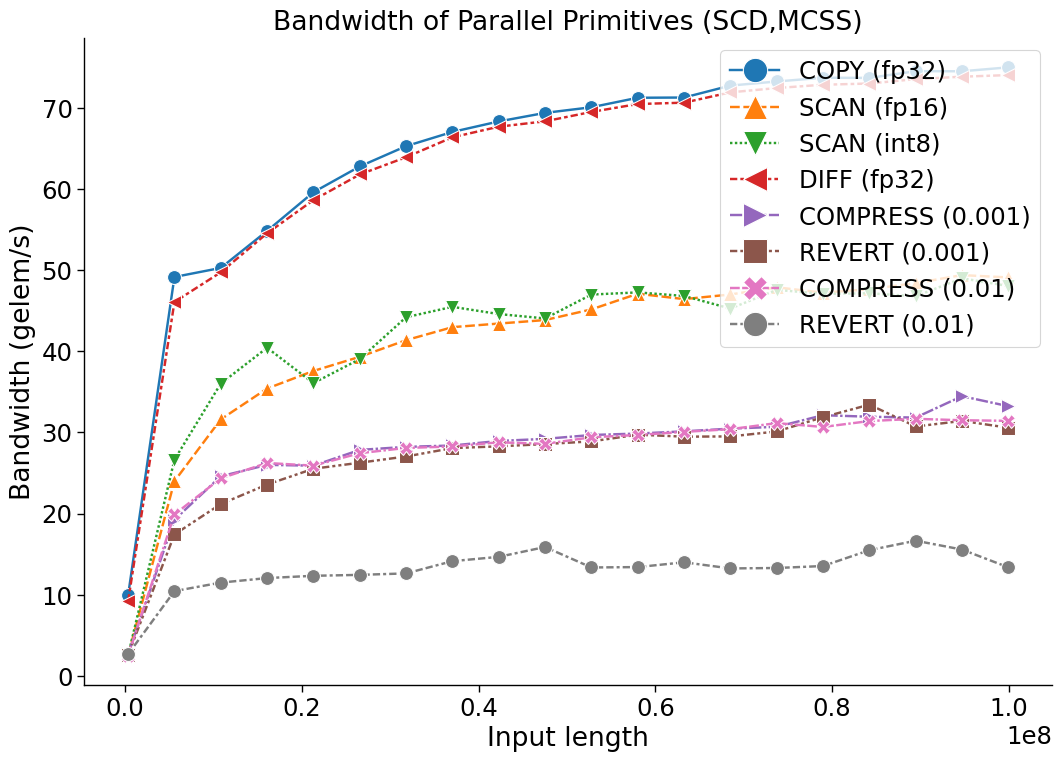

<Figure size 870x627 with 0 Axes>

In [79]:
plt.figure(figsize=(11, 8))


_SNS_PARAMS = {"hue":'operator', "style":'operator', "markers":_MARKERS, "markersize": 10, "dashes":True}

ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"Bandwidth of Parallel Primitives (SCD,MCSS)")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (gelem/s)")
sns.despine(right = True)
plt.legend(loc="upper right", markerscale=_LEGEND_MARKER_SCALE)
plt.tight_layout()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"bw_gelemps_mc_seg_ops.pdf")
fig.savefig(f"bw_gelemps_mc_seg_ops.png")
plt.show()
plt.clf()